In [1]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
import scipy as sp
import scipy.signal as signal
import torchvision.transforms.functional as tvF

import math

In [2]:
save_dir = '/content/drive/MyDrive/Project/PlasticityDecoding/result'

acu_set_TCNN = np.load(save_dir + '/TCNN_fixedrepresentation.npy')
acu_set_TTE = np.load(save_dir + '/TTE_fixedrepresentation.npy')
acu_set_SVM = np.load(save_dir + '/svm_fixedrepresentation.npy')

In [3]:
def barplot_annotate_brackets(num1, num2, data, center, height, yerr=None, dh=.05, barh=.05, fs=None, maxasterix=None):
    """
    Annotate barplot with p-values.

    :param num1: number of left bar to put bracket over
    :param num2: number of right bar to put bracket over
    :param data: string to write or number for generating asterixes
    :param center: centers of all bars (like plt.bar() input)
    :param height: heights of all bars (like plt.bar() input)
    :param yerr: yerrs of all bars (like plt.bar() input)
    :param dh: height offset over bar / bar + yerr in axes coordinates (0 to 1)
    :param barh: bar height in axes coordinates (0 to 1)
    :param fs: font size
    :param maxasterix: maximum number of asterixes to write (for very small p-values)
    """

    if type(data) is str:
        text = data
    else:
        # * is p < 0.01
        # ** is p < 0.001
        # *** is p < 0.0001
        # etc.
        text = ''
        p = .01

        while data < p:
            text += '*'
            p /= 10.

            if maxasterix and len(text) == maxasterix:
                break

        if len(text) == 0:
            text = 'n. s.'

    lx, ly = center[num1], height[num1]
    rx, ry = center[num2], height[num2]

    if yerr:
        ly += yerr[num1]
        ry += yerr[num2]

    ax_y0, ax_y1 = plt.gca().get_ylim()
    dh *= (ax_y1 - ax_y0)
    barh *= (ax_y1 - ax_y0)

    y = max(ly, ry) + dh

    barx = [lx, lx, rx, rx]
    bary = [y, y+barh, y+barh, y]
    mid = ((lx+rx)/2, y+barh)

    plt.plot(barx, bary, c='black')

    kwargs = dict(ha='center', va='bottom')
    if fs is not None:
        kwargs['fontsize'] = fs

    plt.text(*mid, text, **kwargs)

In [4]:
print(sp.stats.normaltest(acu_set_SVM[:,0]))
print(sp.stats.normaltest(acu_set_TCNN[:,1]))
print(sp.stats.normaltest(acu_set_TTE[:,1]))

NormaltestResult(statistic=1.4001980581143967, pvalue=0.49653612985182116)
NormaltestResult(statistic=3.3653618551356743, pvalue=0.1858749900805914)
NormaltestResult(statistic=1.7961980382975102, pvalue=0.4073432759603033)


In [5]:
print(sp.stats.levene(acu_set_SVM[:,0], acu_set_TCNN[:,1]))
print(sp.stats.levene(acu_set_TCNN[:,1], acu_set_TTE[:,1]))


LeveneResult(statistic=0.8528915616216454, pvalue=0.3580039019859198)
LeveneResult(statistic=0.906103939084426, pvalue=0.34349212015268205)


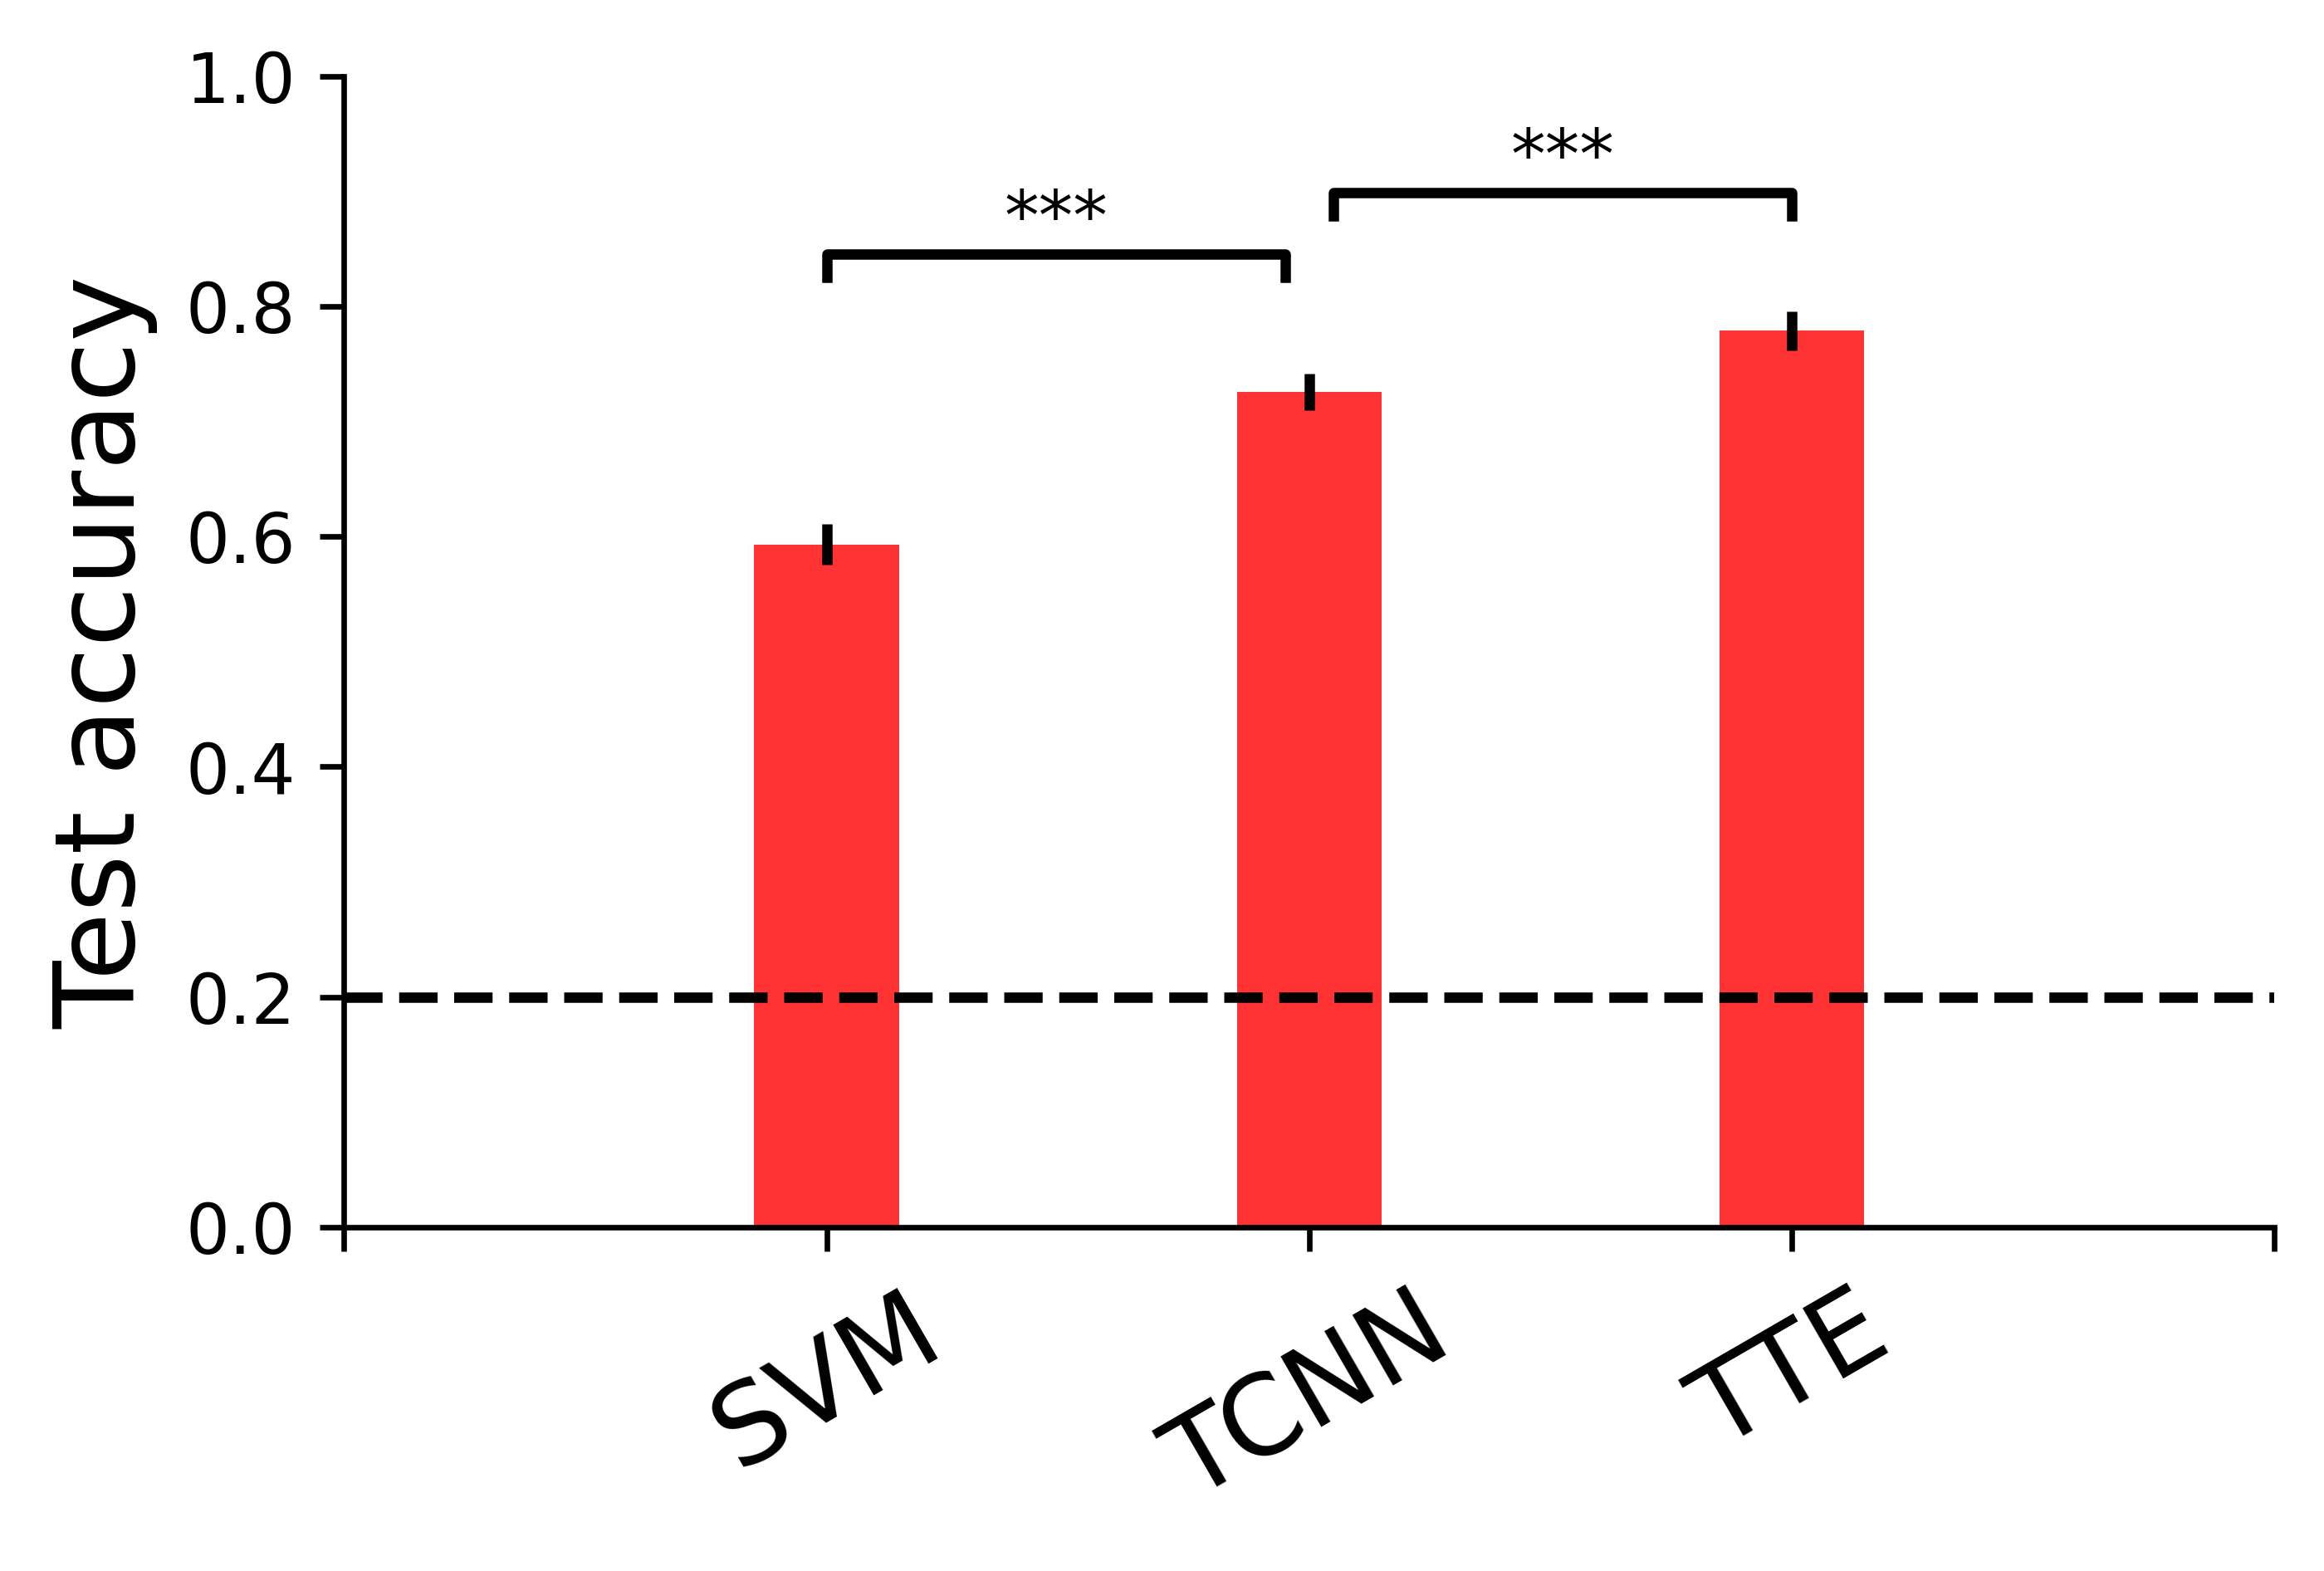

In [6]:
fig, ax = plt.subplots(figsize = (5,3),dpi=600)
ax.bar(1.0, acu_set_SVM[:,0].mean(), width=0.3, yerr=acu_set_SVM[:,0].std(),color='red',label='Overall',alpha=0.8)
ax.bar(2.0, acu_set_TCNN[:,1].mean(), width=0.3, yerr=acu_set_TCNN[:,1].std(),color='red',label='Overall',alpha=0.8)
ax.bar(3.0, acu_set_TTE[:,1].mean(), width=0.3, yerr=acu_set_TTE[:,1].std(),color='red',alpha=0.8)
plt.xticks(range(0,5),('', 'SVM', 'TCNN','TTE',''),rotation=30,fontsize=16)
plt.ylim([0.0, 1.0])
plt.ylabel('Test accuracy',fontsize=16)
barplot_annotate_brackets(1, 2, sp.stats.mstats.ttest_ind(acu_set_SVM[:,0], acu_set_TCNN[:,1])[1], np.array([1, 1, 2 - 0.05, 2 - 0.05]),
                          [acu_set_SVM[:,0].mean(), acu_set_SVM[:,0].mean(), acu_set_TCNN[:,1].mean(), acu_set_TCNN[:,1].mean()], dh=0.10, barh=.02, maxasterix=3)
barplot_annotate_brackets(1, 2, sp.stats.mstats.ttest_ind(acu_set_TCNN[:,1], acu_set_TTE[:,1])[1], np.array([2 + 0.05, 2 + 0.05, 3, 3]),
                          [acu_set_TCNN[:,1].mean(), acu_set_TCNN[:,1].mean(), acu_set_TTE[:,1].mean(), acu_set_TTE[:,1].mean()], dh=0.10, barh=.02, maxasterix=3)
# plt.legend(loc='lower left')
plt.plot([0, 4], [0.2, 0.2], 'k--')
plt.xlim([0, 4])
sns.despine()
plt.show()

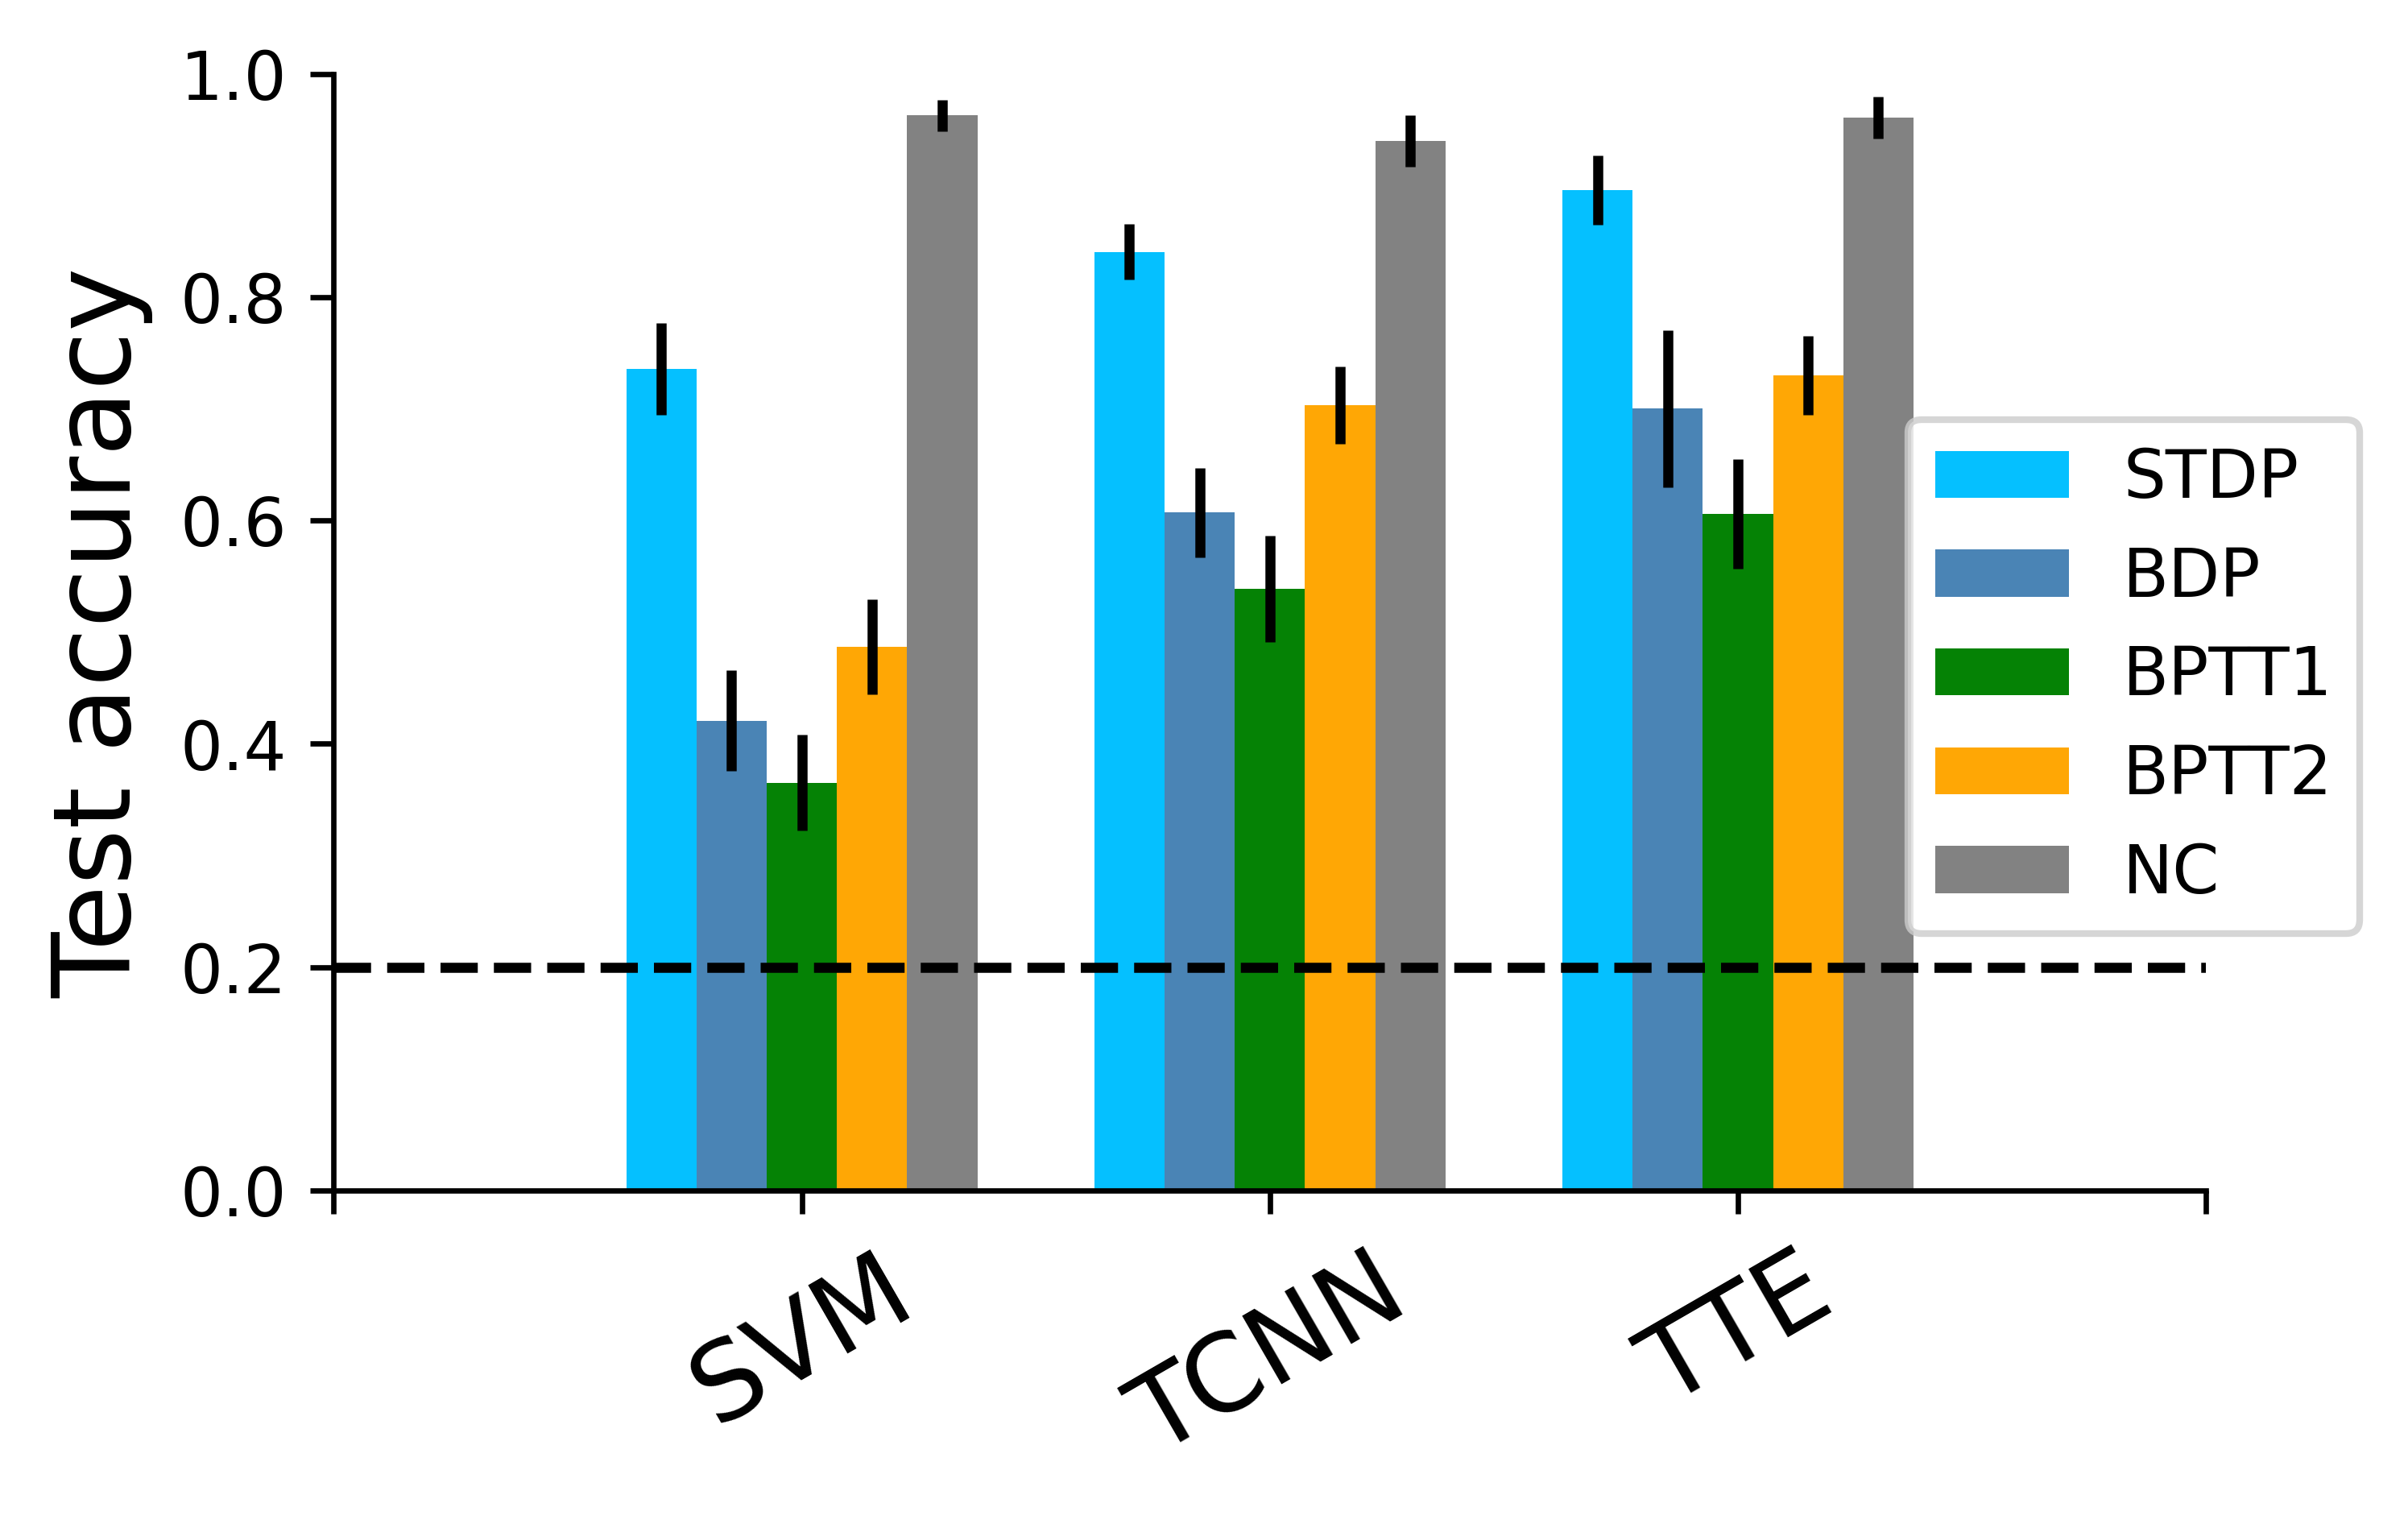

In [7]:
fig, ax = plt.subplots(figsize = (5,3),dpi=600)

ax.bar(1.0 - 0.3, acu_set_SVM[:,1].mean(), width=0.15, yerr=acu_set_SVM[:,1].std(),color='deepskyblue',label='STDP',alpha=0.98)
ax.bar(1.0 - 0.15, acu_set_SVM[:,2].mean(), width=0.15, yerr=acu_set_SVM[:,2].std(),color='steelblue',label='BDP',alpha=0.98)
ax.bar(1.0, acu_set_SVM[:,3].mean(), width=0.15, yerr=acu_set_SVM[:,3].std(),color='green',label='BPTT1',alpha=0.98)
ax.bar(1.0 + 0.15, acu_set_SVM[:,4].mean(), width=0.15, yerr=acu_set_SVM[:,4].std(),color='orange',label='BPTT2',alpha=0.98)
ax.bar(1.0 + 0.3, acu_set_SVM[:,5].mean(), width=0.15, yerr=acu_set_SVM[:,5].std(),color='gray',label='NC',alpha=0.98)
plt.legend(loc='lower right', bbox_to_anchor=(1.1, 0.2))

ax.bar(2.0 - 0.3, acu_set_TCNN[:,3].mean(), width=0.15, yerr=acu_set_TCNN[:,3].std(),color='deepskyblue',label='STDP',alpha=0.98)
ax.bar(2.0 - 0.15, acu_set_TCNN[:,5].mean(), width=0.15, yerr=acu_set_TCNN[:,5].std(),color='steelblue',label='BDP',alpha=0.98)
ax.bar(2.0, acu_set_TCNN[:,7].mean(), width=0.15, yerr=acu_set_TCNN[:,7].std(),color='green',label='BPTT1',alpha=0.98)
ax.bar(2.0 + 0.15, acu_set_TCNN[:,9].mean(), width=0.15, yerr=acu_set_TCNN[:,9].std(),color='orange',label='BPTT2',alpha=0.98)
ax.bar(2.0 + 0.3, acu_set_TCNN[:,11].mean(), width=0.15, yerr=acu_set_TCNN[:,11].std(),color='gray',label='NC',alpha=0.98)

ax.bar(3.0 - 0.3, acu_set_TTE[:,3].mean(), width=0.15, yerr=acu_set_TTE[:,3].std(),color='deepskyblue',label='STDP',alpha=0.98)
ax.bar(3.0 - 0.15, acu_set_TTE[:,5].mean(), width=0.15, yerr=acu_set_TTE[:,5].std(),color='steelblue',label='BDP',alpha=0.98)
ax.bar(3.0, acu_set_TTE[:,7].mean(), width=0.15, yerr=acu_set_TTE[:,7].std(),color='green',label='BPTT1',alpha=0.98)
ax.bar(3.0 + 0.15, acu_set_TTE[:,9].mean(), width=0.15, yerr=acu_set_TTE[:,9].std(),color='orange',label='BPTT2',alpha=0.98)
ax.bar(3.0 + 0.3, acu_set_TTE[:,11].mean(), width=0.15, yerr=acu_set_TTE[:,11].std(),color='gray',label='NC',alpha=0.98)
plt.xticks(range(0,5),('', 'SVM', 'TCNN','TTE',''),rotation=30,fontsize=16)
plt.ylim([0.0, 1.0])
plt.ylabel('Test accuracy',fontsize=16)
plt.plot([0, 4], [0.2, 0.2], 'k--')
plt.xlim([0, 4])
sns.despine()
plt.show()